# **Capstone Project: A Bi-Objective Evolutionary Approach to Feature Selection for Customer Value Prediction in Fintech**

# *Visualization Refinement*

## MBAI 5600G: Applied Integrative Analytics Capstone Project

### Group 7: Brennan Mason & Mohammad Shah

## Environment Setup

In [ ]:
# Specify base path to local directory
BASE_PATH = "/content/drive/Shareddrives/MBAI Capstone S S26 Group 7/"

In [ ]:
!pip install --upgrade --force-reinstall kaleido==0.2.1
!pip install great_tables

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.4/495.4 kB 34.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
out_path = BASE_PATH + "p2p-customer-value-prediction/reports/figures/"

## Global Style Definition

In [ ]:
# Specify colour palette
palette = {
    "grey_fill": "#7c898b",
    "orange_fill": "#d96c06",
    "blue_fill": "#4a819e",
    "grey_outline": "#2f4346",
    "orange_outline": "#9e4e03",
    "blue_outline": "#2c5063",
    "title": "#1c191a",
    "text": "#253439",
    "grid": "#f0f0f0",
    "axis": "#253439"
}

## Plot Construction

### RAR Target Distribution

In [ ]:
import pandas as pd

path = BASE_PATH + "p2p-customer-value-prediction/data/interim/sampled_loans.csv"

loans = pd.read_csv(path)
loans.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,spread,issue_yr_mnth,avg_spread,min_spread,return,beta,disc_rate,loan_duration,avg_monthly_cash_flow,rar
0,49763530,NaN,7000.0,7000.0,7000.0,36 months,0.0789,219.00,A,A5,...,0.077472,2015-05,0.124520,0.051806,0.124084,0.404783,0.006530,32.0,245.893361,7126.312861
1,1614412,NaN,5000.0,5000.0,5000.0,36 months,0.0603,152.18,A,A1,...,0.058818,2012-10,0.137318,0.058518,0.091950,0.404783,0.007239,29.0,188.267241,4944.316301
2,19435976,NaN,10000.0,10000.0,10000.0,36 months,0.0712,309.32,A,A3,...,0.070246,2014-06,0.138971,0.059056,0.113552,0.404783,0.007315,36.0,309.319915,9830.124029
3,44756872,NaN,12000.0,12000.0,12000.0,36 months,0.0593,364.69,A,A1,...,0.057898,2015-04,0.124802,0.057898,0.093717,0.404783,0.006820,36.0,364.572381,11681.851552
4,108855699,NaN,6700.0,6700.0,6700.0,36 months,0.0532,201.77,A,A1,...,0.042755,2017-05,0.126481,0.042755,0.029875,0.404783,0.006173,8.0,862.520378,6753.795702


In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Histogram(
    x=loans["rar"],
    nbinsx=40,
    marker=dict(
        color=palette["blue_fill"],
        line=dict(
            color=palette["blue_outline"],
            width=1.5
        )
    )
))

fig.update_layout(
    title=dict(
        text="Distribution of Risk-Adjusted Revenue",
        font=dict(
            size=20,
            color=palette["title"],
            weight="bold"
        )
    ),
    xaxis_title="Risk-Adjusted Revenue (USD)",
    yaxis_title="Frequency",
    template="plotly_white",
    font=dict(
        family="Calibri, sans-serif",
        color=palette["text"],
        size=14
    ),
    width=1000,
    height=600
)

fig.update_xaxes(
    title_font=dict(size=16),
    ticklabelstandoff=5,
    tickformat="s",
    tickprefix="$",
    gridcolor=palette["grid"],
    linecolor=palette["axis"],
    linewidth=1.3
)

fig.update_yaxes(
    title_font=dict(size=16),
    ticklabelstandoff=5,
    tickformat="s",
    gridcolor=palette["grid"],
    linecolor=palette["axis"],
    linewidth=1.3
)

fig.write_image(out_path + "01_rar_distribution.png", scale=4)
fig.show()

Output hidden; open in https://colab.research.google.com to view.

### Loan Status Class Distribution

In [ ]:
loans["loan_status"] = loans["loan_status"].replace({"Charged Off": "Charged-Off"})

loans_by_status = loans.groupby("loan_status")["loan_status"].count()

data_labels = []

for val in loans_by_status.values:
  label = f"{val:,.0f} (" + str(int(round(val / loans_by_status.sum() * 100, 0))) + "%)"
  data_labels.append(label)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=loans_by_status.index,
    y=loans_by_status.values,
    marker=dict(
        color=palette["blue_fill"]
    ),
    text=data_labels,
    textposition="inside",
    insidetextanchor="end",
    textfont=dict(
        color="white",
        size=18,
        weight="bold"
    )
))

fig.update_layout(
    title=dict(
        text="Distribution of Loan Status",
        font=dict(
            size=20,
            color=palette["title"],
            weight="bold"
        )
    ),
    xaxis_title="Loan Status",
    yaxis_title="Frequency",
    template="plotly_white",
    font=dict(
        family="Calibri, sans-serif",
        color=palette["text"],
        size=14
    ),
    width=1000,
    height=600
)

fig.update_xaxes(
    title_font=dict(size=16),
    ticklabelstandoff=5,
    linecolor=palette["axis"],
    linewidth=1.3
)

fig.update_yaxes(
    title_font=dict(size=16),
    ticklabelstandoff=5,
    tickformat="s",
    gridcolor=palette["grid"],
    linecolor=palette["axis"],
    linewidth=1.3
)

fig.write_image(out_path + "02_loan_status_class_distribution.png", scale=4)
fig.show()

### Average RAR by Loan Status

In [ ]:
rar_by_status = loans.groupby("loan_status")["rar"].mean()

fig = go.Figure()

fig.add_trace(go.Bar(
    x=rar_by_status.index,
    y=rar_by_status.values,
    marker=dict(
        color=palette["blue_fill"]
    ),
    text=rar_by_status.values,
    texttemplate="$%{text:,.2f}",
    textposition="inside",
    insidetextanchor="end",
    textfont=dict(
        color="white",
        size=18,
        weight="bold"
    )
))

fig.update_layout(
    title=dict(
        text="Average Risk-Adjusted Revenue by Loan Status",
        font=dict(
            size=20,
            color=palette["title"],
            weight="bold"
        )
    ),
    xaxis_title="Loan Status",
    yaxis_title="Average Risk-Adjusted Revenue (USD)",
    template="plotly_white",
    font=dict(
        family="Calibri, sans-serif",
        color=palette["text"],
        size=14
    ),
    width=1000,
    height=600
)

fig.update_xaxes(
    title_font=dict(size=16),
    ticklabelstandoff=5,
    linecolor=palette["axis"],
    linewidth=1.3
)

fig.update_yaxes(
    title_font=dict(size=16),
    ticklabelstandoff=5,
    tickformat="s",
    tickprefix="$",
    gridcolor=palette["grid"],
    linecolor=palette["axis"],
    linewidth=1.3
)

fig.write_image(out_path + "03_avg_rar_by_loan_status.png", scale=4)
fig.show()

### Charge-Off Rate by Loan Grade

In [ ]:
charge_off_mask = loans["loan_status"] == "Charged-Off"
charge_offs_by_grade = loans[charge_off_mask].groupby("grade")["loan_status"].count()
charge_offs_by_grade.rename("n_charge_offs", inplace=True)

loans_by_grade = loans.groupby("grade")["loan_status"].count()
loans_by_grade.rename("n_loans", inplace=True)

rate_by_grade = pd.concat([charge_offs_by_grade, loans_by_grade], axis=1)
rate_by_grade["rate"] = rate_by_grade["n_charge_offs"] / rate_by_grade["n_loans"]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=rate_by_grade.index,
    y=rate_by_grade["rate"],
    marker=dict(
        color=palette["blue_fill"]
    ),
    text=rate_by_grade["rate"],
    texttemplate="%{text:.1%}",
    textposition="inside",
    insidetextanchor="end",
    textfont=dict(
        color="white",
        size=18,
        weight="bold"
    )
))

fig.update_layout(
    title=dict(
        text="Charge-Off Rate by Loan Grade",
        font=dict(
            size=20,
            color=palette["title"],
            weight="bold"
        )
    ),
    xaxis_title="Loan Grade",
    yaxis_title="Charge-Off Rate",
    template="plotly_white",
    font=dict(
        family="Calibri, sans-serif",
        color=palette["text"],
        size=14
    ),
    width=1000,
    height=600
)

fig.update_xaxes(
    title_font=dict(size=16),
    ticklabelstandoff=5,
    linecolor=palette["axis"],
    linewidth=1.3
)

fig.update_yaxes(
    title_font=dict(size=16),
    ticklabelstandoff=5,
    tickformat=".0%",
    gridcolor=palette["grid"],
    linecolor=palette["axis"],
    linewidth=1.3
)

fig.write_image(out_path + "04_charge_off_rate_by_loan_grade.png", scale=4)
fig.show()

### Systematic Risk by Loan Grade

In [ ]:
beta_by_grade = loans.groupby("grade")["beta"].mean()

fig = go.Figure()

fig.add_trace(go.Bar(
    x=beta_by_grade.index,
    y=beta_by_grade.values,
    marker=dict(
        color=palette["blue_fill"]
    ),
    text=beta_by_grade.values,
    texttemplate="%{text:.1f}",
    textposition="inside",
    insidetextanchor="end",
    textfont=dict(
        color="white",
        size=18,
        weight="bold"
    )
))

fig.update_layout(
    title=dict(
        text=r"Systematic Risk by Loan Grade",
        font=dict(
            size=20,
            color=palette["title"],
            weight="bold"
        ),
        subtitle=dict(
            text="Baseline Market Risk = 1.0",
            font=dict(
                size=18,
                color=palette["text"]
            )
        )
    ),
    xaxis_title="Loan Grade",
    yaxis_title="Systematic Risk (Beta)",
    template="plotly_white",
    font=dict(
        family="Calibri, sans-serif",
        color=palette["text"],
        size=14
    ),
    width=1000,
    height=600
)

fig.update_xaxes(
    title_font=dict(size=16),
    ticklabelstandoff=5,
    linecolor=palette["axis"],
    linewidth=1.3
)

fig.update_yaxes(
    title_font=dict(size=16),
    ticklabelstandoff=5,
    tickformat=".1f",
    gridcolor=palette["grid"],
    linecolor=palette["axis"],
    linewidth=1.3
)

fig.write_image(out_path + "05_beta_by_loan_grade.png", scale=4)
fig.show()

### Pareto Front

In [ ]:
pareto_df = pd.DataFrame({
    "Solution": [i + 1 for i in range(11)],
    "Feature Count": [16, 11, 17, 13, 20, 19, 15, 12, 14, 22, 9],
    "MAE": [2605.5612, 5724.0252, 2603.5201, 2613.2293, 2589.4517, 2596.5796, 2608.5933, 2624.2665, 2609.3743, 2584.0777, 5823.6407]
})

pareto_df.sort_values(by="Feature Count", ascending=True, inplace=True)

In [ ]:
from plotly.subplots import make_subplots

selected_idx = 7
selected_n_feats = pareto_df.loc[selected_idx, "Feature Count"]
selected_mae = pareto_df.loc[selected_idx, "MAE"]

fig = make_subplots(
    rows=1,
    cols=2,
    horizontal_spacing=0.12,
    subplot_titles=(
        "<b>Macro View: Full Frontier</b>",
        "<b>Micro View: Diminishing Returns Region</b>"
    )
)

for col in range(1, 3):
  fig.add_trace(go.Scatter(
      x=pareto_df["Feature Count"],
      y=pareto_df["MAE"],
      mode="lines+markers",
      line=dict(color=palette["blue_fill"], width=2),
      marker=dict(color=palette["blue_fill"], size=16, line=dict(color=palette["blue_outline"], width=1.5)),
      showlegend=False
  ), row=1, col=col)

  fig.add_trace(go.Scatter(
      x=[selected_n_feats],
      y=[selected_mae],
      mode="markers",
      marker=dict(color=palette["orange_fill"], size=16, line=dict(color=palette["orange_outline"], width=1.5)),
      showlegend=False
  ), row=1, col=col)

x1, x2 = 11.5, 22.5
y1, y2 = 2500, 2700

title_text = (
    "<b><span style='font-size:20px; color:#1c191a;'>NSGA-II Pareto-Optimal Front</span></b><br>"
    "<span style='font-size:18px; color:#4a819e;'><b>Candidate Solutions</b></span> "
    "&nbsp;<span style='font-size:18px; color:#253439;'><b>|</b></span>&nbsp; "
    "<span style='font-size:18px; color:#D96C06;'><b>Selected Solution</b></span>"
)

fig.update_layout(
    title=dict(
        text=title_text,
        x=0.05,
        y=0.95
    ),
    template="plotly_white",
    font=dict(
        family="Calibri, sans-serif",
        color=palette["text"],
        size=14
    ),
    width=1100,
    height=550

)

for annotation in fig["layout"]["annotations"]:
  annotation["font"] = dict(size=16, color=palette["title"])

fig.update_xaxes(
    title_text="<i>f<sub>1</sub></i> (Number of Features)",
    title_font=dict(size=16),
    ticklabelstandoff=5,
    gridcolor=palette["grid"],
    linecolor=palette["axis"],
    linewidth=1.3
)

fig.update_yaxes(
    title_text="<i>f<sub>2</sub></i> (Mean Absolute Error)",
    title_font=dict(size=16),
    ticklabelstandoff=5,
    tickformat="$,.0f",
    gridcolor=palette["grid"],
    linecolor=palette["axis"],
    linewidth=1.3
)

fig.update_xaxes(range=[x1, x2], row=1, col=2)
fig.update_yaxes(range=[y1, y2], row=1, col=2)

fig.write_image(out_path + "06_pareto_front.png", scale=4)
fig.show()

### Performance by Model

In [ ]:
eval_df = pd.DataFrame({
    "Experiment": ["EC1 - GB", "EC4 - PCA + GB", "EC5 - SGA + GB", "EC6 - NSGA-II + GB", "EC7 - HPO + GB"],
    "Adjusted R-squared": [0.7582, 0.7182, 0.7584, 0.7562, 0.7660],
    "MAE": [2611.06, 3250.45, 2606.39, 2628.86, 2606.42],
    "Feature Count": [126, 45, 86, 49, 49]
})

In [ ]:
# Define func to map fill colours
def map_fill_colours(row):
  exp = row["Experiment"]
  if exp == "EC1 - GB":
    return palette["grey_fill"]
  elif exp == "EC7 - HPO + GB":
    return palette["orange_fill"]
  else:
    return palette["blue_fill"]

# Define func to map outline colours
def map_outline_colours(row):
  exp = row["Experiment"]
  if exp == "EC1 - GB":
    return palette["grey_outline"]
  elif exp == "EC7 - HPO + GB":
    return palette["orange_outline"]
  else:
    return palette["blue_outline"]

eval_df["Fill Colour"] = eval_df.apply(map_fill_colours, axis=1)
eval_df["Outline Colour"] = eval_df.apply(map_outline_colours, axis=1)

In [ ]:
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05
)

fig.add_trace(go.Bar(
    x=eval_df["Experiment"],
    y=eval_df["Feature Count"],
    marker=dict(
        color=eval_df["Fill Colour"]
    ),
    text=eval_df["Feature Count"],
    texttemplate="%{text:.0f}",
    textposition="inside",
    insidetextanchor="end",
    textfont=dict(
        color="white",
        size=18,
        weight="bold"
    ),
    showlegend=False
), row=1, col=1)

fig.add_trace(go.Bar(
    x=eval_df["Experiment"],
    y=eval_df["Adjusted R-squared"],
    marker=dict(
        color=eval_df["Fill Colour"]
    ),
    text=eval_df["Adjusted R-squared"],
    texttemplate="%{text:.3f}",
    textposition="inside",
    insidetextanchor="end",
    textfont=dict(
        color="white",
        size=18,
        weight="bold"
    ),
    showlegend=False
), row=2, col=1)

fig.update_layout(
    title=dict(
        text="Model Performance Comparison: Feature Count & Adjusted <i>R</i><sup>2</sup>",
        font=dict(
            size=20,
            color=palette["title"],
            weight="bold"
        ),
        subtitle=dict(
            text="<b><span style='color: #7c898b;'>Baseline</span></b> &nbsp;|&nbsp; <b><span style='color: #4a819e;'>Advanced</span></b> &nbsp;|&nbsp; <b><span style='color: #d96c06;'>Optimized</span></b>",
            font=dict(
                size=18,
                color=palette["text"]
            )
        )
    ),
    template="plotly_white",
    font=dict(
        family="Calibri, sans-serif",
        color=palette["text"],
        size=14
    ),
    width=1000,
    height=800
)

fig.update_xaxes(
    title_text="Model",
    title_font=dict(size=16),
    ticklabelstandoff=5,
    linecolor=palette["axis"],
    linewidth=1.3,
    row=2,
    col=1
)

fig.update_xaxes(
    linecolor=palette["axis"],
    linewidth=1.3,
    row=1,
    col=1
)

fig.update_yaxes(
    title_text="Number of Features",
    title_font=dict(size=16),
    ticklabelstandoff=5,
    tickformat=".0f",
    gridcolor=palette["grid"],
    linecolor=palette["axis"],
    linewidth=1.3,
    rangemode="tozero",
    row=1,
    col=1
)

fig.update_yaxes(
    title_text="Adjusted <i>R</i><sup>2</sup>",
    title_font=dict(size=16),
    ticklabelstandoff=5,
    tickformat=".1f",
    gridcolor=palette["grid"],
    linecolor=palette["axis"],
    linewidth=1.3,
    rangemode="tozero",
    row=2,
    col=1
)

fig.write_image(out_path + "07_model_performance.png", scale=4)
fig.show()

### Baseline vs Optimized Model Comparison Table

In [ ]:
!apt-get remove -y chromium-browser

!wget -q -O - https://dl.google.com/linux/linux_signing_key.pub | apt-key add -
!sh -c 'echo "deb [arch=amd64] http://dl.google.com/linux/chrome/deb/ stable main" >> /etc/apt/sources.list.d/google-chrome.list'
!apt-get update
!apt-get install -y google-chrome-stable
!pip install html2image

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Package 'chromium-browser' is not installed, so not removed
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
OK
Get:1 http://dl.google.com/linux/chrome/deb stable InRelease [2,548 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://dl.google.com/linux/chrome/deb sta

In [ ]:
from great_tables import GT, loc, md, google_font, style
from html2image import Html2Image
import os

comparison_df = pd.DataFrame({
    "Model": ["Baseline", "Optimized", "Absolute Change", "Relative Change"],
    "Adjusted R-Squared (↑)": ["0.758", "0.766", "▲ 0.008", "▲ 1.0%"],
    "MAE (↓)": ["$2,611.06", "$2,606.42", "▼ $4.64", "▼ 0.2%"],
    "Raw Feature Count (↓)": ["61", "12", "▼ 49", "▼ 80.3%"],
    "Encoded Feature Count (↓)": ["126", "49", "▼ 77", "▼ 61.1%"],
    "Training Time (↓)": ["7.68 s", "16.58 s", "▲ 8.90 s", "▲ 115.9%"],
    "Inference Time (↓)": ["0.92 s", "2.10 s", "▲ 1.18 s", "▲ 128.3%"]
})

comparison_tbl = (
    GT(comparison_df)
    .tab_header(
        title=md("**Model Performance Comparison**"),
        subtitle=md(
            f"<span style='font-size: 16px'>Baseline vs. Optimized</span><br>"
            f"<b><span style='color:#0c9e5a'>Better</span></b> &nbsp;|&nbsp; "
            f"<b><span style='color:#b22b27'>Worse</span></b>"
        )
    )
    .tab_spanner(
        label="Evaluation Metrics",
        columns=["Adjusted R-Squared (↑)", "MAE (↓)", "Raw Feature Count (↓)", "Encoded Feature Count (↓)", "Training Time (↓)", "Inference Time (↓)"]
    )
    .cols_align(align="right", columns=comparison_df.columns[1:].to_list())
    .cols_align(align="left", columns=["Model"])
    .tab_style(
        style=style.borders(sides=["top"], color="#d3d3d3", weight="2px"),
        locations=loc.body(rows=[2])
    )
    .tab_style(
        style=style.text(weight="bold"),
        locations=loc.body(columns=["Model"], rows=[2, 3])
    )
    .tab_style(
        style=[style.text(color="#0c9e5a"), style.fill(color="#e8f5e9")],
        locations=loc.body(columns=["Adjusted R-Squared (↑)"], rows=[2, 3])
    )
    .tab_style(
        style=[style.text(color="#0c9e5a"), style.fill(color="#e8f5e9")],
        locations=loc.body(columns=["MAE (↓)", "Raw Feature Count (↓)", "Encoded Feature Count (↓)"], rows=[2, 3])
    )
    .tab_style(
        style=[style.text(color="#b22b27"), style.fill(color="#fbd5d3")],
        locations=loc.body(columns=["Training Time (↓)", "Inference Time (↓)"], rows=[2, 3])
    )
    .opt_table_font(font=google_font(name="Carlito"))
    .opt_align_table_header(align="left")
    .tab_options(table_font_color=palette["text"], column_labels_font_weight="bold", data_row_padding="8px")
    .tab_style(
        style=style.text(color=palette["title"]),
        locations=loc.title()
    )
)

hti = Html2Image(custom_flags=[
    '--no-sandbox',
    '--disable-gpu',
    '--headless',
    '--force-device-scale-factor=3',
    '--default-background-color=FFFFFF'
])

hti.browser_executable = '/usr/bin/google-chrome'
hti.output_path = '/content/'

html_str = comparison_tbl.as_raw_html()
hti.screenshot(
    html_str=html_str,
    save_as='08_baseline_vs_optimized_table.png',
    size=(1200, 600)
)

comparison_tbl.show()

Model Performance Comparison 
 
 
 Baseline vs. Optimized Better  |  Worse 
 
 
 Model 
 
 Evaluation Metrics 
 
 
 
 Adjusted R-Squared (↑) 
 MAE (↓) 
 Raw Feature Count (↓) 
 Encoded Feature Count (↓) 
 Training Time (↓) 
 Inference Time (↓) 
 
 
 
 
 Baseline 
 0.758 
 $2,611.06 
 61 
 126 
 7.68 s 
 0.92 s 
 
 
 Optimized 
 0.766 
 $2,606.42 
 12 
 49 
 16.58 s 
 2.10 s 
 
 
 Absolute Change 
 ▲ 0.008 
 ▼ $4.64 
 ▼ 49 
 ▼ 77 
 ▲ 8.90 s 
 ▲ 1.18 s 
 
 
 Relative Change 
 ▲ 1.0% 
 ▼ 0.2% 
 ▼ 80.3% 
 ▼ 61.1% 
 ▲ 115.9% 
 ▲ 128.3%

In [ ]:
from google.colab import files
files.download('08_baseline_vs_optimized_table.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Descriptive Statistics Summary Table

In [ ]:
key_vars = ["funded_amnt", "int_rate", "installment", "annual_inc", "rar"]

summary_df = loans[key_vars].describe()
summary_df.drop("count", axis=0, inplace=True)
summary_df = summary_df.reset_index().rename(columns={"index": "metric"})
display(summary_df)

,metric,funded_amnt,int_rate,installment,annual_inc,rar
0,mean,14433.762913,0.132349,438.809080,7.633587e+04,13352.550271
1,std,8714.084748,0.047632,261.666456,6.300569e+04,9094.520021
2,min,1000.000000,0.053100,14.010000,0.000000e+00,35.689585
3,25%,8000.000000,0.097500,249.540000,4.600000e+04,6249.460920
4,50%,12000.000000,0.127400,375.430000,6.500000e+04,10863.350183
5,75%,20000.000000,0.159900,581.690000,9.000000e+04,18485.394038
6,max,40000.000000,0.309900,1714.540000,7.200000e+06,50915.728623


In [ ]:
summary_tbl = (
    GT(summary_df)
    .tab_header(
        title=md("**Descriptive Statistics Summary**"),
        subtitle=md(f"<span style='font-size: 16px'>For Select Variables</span>")
    )
    .tab_spanner(
        label="Variables",
        columns=key_vars
    )
    .fmt_currency(
        columns=[var for var in key_vars if var != "int_rate"]
    )
    .fmt_percent(
        columns="int_rate"
    )
    .cols_label(
        **{
            "metric": "Metric",
            "funded_amnt": "Funded Amount",
            "int_rate": "Interest Rate",
            "installment": "Installment",
            "annual_inc": "Annual Income",
            "rar": "Risk-Adjusted Revenue"
        }
    )
    .cols_align(align="right", columns=key_vars)
    .cols_align(align="left", columns=["metric"])
    .opt_table_font(font=google_font(name="Carlito"))
    .opt_align_table_header(align="left")
    .tab_options(table_font_color=palette["text"], column_labels_font_weight="bold", data_row_padding="8px")
    .tab_style(
        style=style.text(color=palette["title"]),
        locations=loc.title()
    )
)

html_str = summary_tbl.as_raw_html()
hti.screenshot(
    html_str=html_str,
    save_as='09_desc_stats_summary_table.png',
    size=(1200, 600)
)

summary_tbl.show()

Descriptive Statistics Summary 
 
 
 For Select Variables 
 
 
 Metric 
 
 Variables 
 
 
 
 Funded Amount 
 Interest Rate 
 Installment 
 Annual Income 
 Risk-Adjusted Revenue 
 
 
 
 
 mean 
 $14,433.76 
 13.23% 
 $438.81 
 $76,335.87 
 $13,352.55 
 
 
 std 
 $8,714.08 
 4.76% 
 $261.67 
 $63,005.69 
 $9,094.52 
 
 
 min 
 $1,000.00 
 5.31% 
 $14.01 
 $0.00 
 $35.69 
 
 
 25% 
 $8,000.00 
 9.75% 
 $249.54 
 $46,000.00 
 $6,249.46 
 
 
 50% 
 $12,000.00 
 12.74% 
 $375.43 
 $65,000.00 
 $10,863.35 
 
 
 75% 
 $20,000.00 
 15.99% 
 $581.69 
 $90,000.00 
 $18,485.39 
 
 
 max 
 $40,000.00 
 30.99% 
 $1,714.54 
 $7,200,000.00 
 $50,915.73

In [ ]:
from google.colab import files
files.download('09_desc_stats_summary_table.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### RAR Distribution by Loan Grade

In [ ]:
fig = go.Figure()

fig.add_trace(go.Box(
    x=loans["grade"],
    y=loans["rar"],
    marker=dict(
        color=palette["blue_fill"],
        # opacity=0.2,
        # size=3
    ),
    name="RAR",
    boxmean=True,
    boxpoints=False,
    # jitter=0.5,
    # pointpos=0
))

fig.update_layout(
    title=dict(
        text="Distribution of Risk-Adjusted Revenue by Loan Grade",
        font=dict(
            size=20,
            color=palette["title"],
            weight="bold"
        )
    ),
    xaxis_title="Loan Grade",
    yaxis_title="Risk-Adjusted Revenue (USD)",
    template="plotly_white",
    font=dict(
        family="Calibri, sans-serif",
        color=palette["text"],
        size=14
    ),
    width=1000,
    height=600
)

fig.update_xaxes(
    categoryorder="category ascending",
    title_font=dict(size=16),
    ticklabelstandoff=5,
    linecolor=palette["axis"],
    linewidth=1.3
)

fig.update_yaxes(
    title_font=dict(size=16),
    ticklabelstandoff=5,
    tickformat="s",
    tickprefix="$",
    gridcolor=palette["grid"],
    linecolor=palette["axis"],
    linewidth=1.3
)

fig.add_annotation(
    text="* Note: Statistical outliers not shown.",
    xref="paper",
    yref="paper",
    x=0,
    y=-0.125,
    showarrow=False,
    font=dict(
        family="Calibri, sans-serif",
        color=palette["text"],
        size=12
    ),
    xanchor="left",
    yanchor="top"
)

fig.write_image(out_path + "10_rar_dist_by_loan_grade.png", scale=4)
fig.show()

Output hidden; open in https://colab.research.google.com to view.

### Correlation Heatmap

In [ ]:
# Specify and drop intermediate features used to derive the target variable
cols = [
    "avg_cdi_rate",
    "spread",
    "issue_yr_mnth",
    "avg_spread",
    "min_spread",
    "return",
    "beta",
    "disc_rate",
    "loan_duration",
    "avg_monthly_cash_flow"
]

loans.drop(cols, axis=1, inplace=True)

In [ ]:
corr_matrix = loans.corr(numeric_only=True)

n = 10
corr_cols = corr_matrix.abs().nlargest(n + 1, "rar")["rar"].index.to_list()
top_corr_matrix = corr_matrix.loc[corr_cols, corr_cols]

top_corr_matrix

,rar,total_pymnt,total_pymnt_inv,total_rec_prncp,funded_amnt,loan_amnt,funded_amnt_inv,installment,last_pymnt_amnt,total_rec_int,settlement_amount
rar,1.000000,0.990046,0.989453,0.981023,0.869934,0.869561,0.869323,0.834317,0.656137,0.618193,0.458282
total_pymnt,0.990046,1.000000,0.999335,0.967126,0.856621,0.856326,0.855986,0.818179,0.586472,0.705557,0.402601
total_pymnt_inv,0.989453,0.999335,1.000000,0.966536,0.856246,0.855871,0.856995,0.817751,0.586871,0.704842,0.402549
total_rec_prncp,0.981023,0.967126,0.966536,1.000000,0.795276,0.794904,0.794728,0.771478,0.663148,0.517868,0.062069
funded_amnt,0.869934,0.856621,0.856246,0.795276,1.000000,0.999563,0.999136,0.953989,0.502856,0.627084,0.806635
loan_amnt,0.869561,0.856326,0.855871,0.794904,0.999563,1.000000,0.998614,0.953380,0.502457,0.627211,0.806775
funded_amnt_inv,0.869323,0.855986,0.856995,0.794728,0.999136,0.998614,1.000000,0.953048,0.503213,0.626415,0.806606
installment,0.834317,0.818179,0.817751,0.771478,0.953989,0.953380,0.953048,1.000000,0.440984,0.561985,0.745226
last_pymnt_amnt,0.656137,0.586472,0.586871,0.663148,0.502856,0.502457,0.503213,0.440984,1.000000,0.135685,0.313739
total_rec_int,0.618193,0.705557,0.704842,0.517868,0.627084,0.627211,0.626415,0.561985,0.135685,1.000000,0.392766


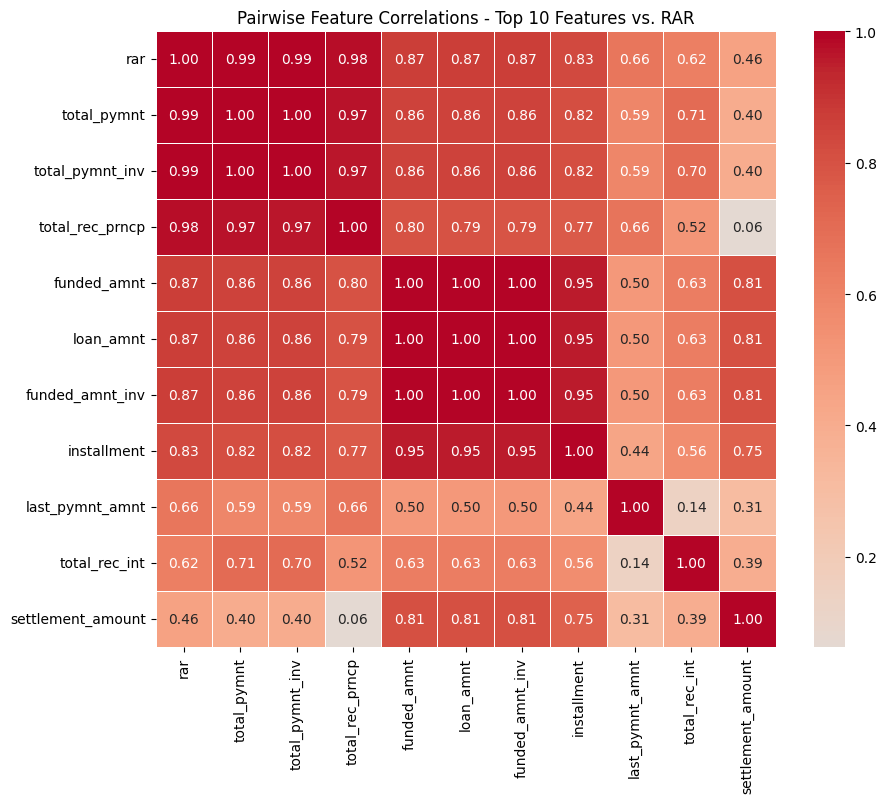

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    top_corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    center=0,
    linewidths=0.5
)

plt.title("Pairwise Feature Correlations - Top 10 Features vs. RAR")
plt.savefig(out_path + "11_corr_heatmap.png", dpi=500, bbox_inches="tight")
plt.show()

### Overall Eval Summary Table

In [ ]:
import pickle

path = BASE_PATH + "p2p-customer-value-prediction/outputs/eval_dict.pkl"

with open(path, "rb") as f:
  eval_dict = pickle.load(f)

In [ ]:
eval_df = pd.DataFrame(eval_dict)
display(eval_df)

,Condition,Model,R-squared,Adjusted R-squared,MAE,MAPE,Fit Time (s),Score Time (s),Feature Count
0,1,DT,0.65978,0.65944,2763.74941,0.41043,10.09391,0.65764,126.0
1,1,RF,0.76628,0.76605,2602.21147,0.39914,151.58900,1.35247,126.0
2,1,GB,0.75844,0.75820,2611.05901,0.39917,7.68316,0.91636,126.0
3,2,DT,0.66020,0.65986,2762.60806,0.41020,16.56769,0.99166,126.0
4,2,RF,0.76618,0.76595,2604.09857,0.39917,154.89061,1.49802,126.0
5,2,GB,0.75799,0.75775,2612.97814,0.39921,14.48223,1.16489,126.0
6,3,KM + DT,0.41724,0.41672,5066.65637,0.76599,16.81288,1.07776,113.0
7,3,KM + RF,0.60578,0.60543,4341.80815,0.70868,144.07088,1.94105,113.0
8,3,KM + GB,0.58976,0.58940,4382.82008,0.69152,18.20652,1.27942,113.0


In [ ]:
new_df = pd.DataFrame({
    "Condition": [4, 5, 6, 7],
    "Model": ["PCA + GB", "SGA + GB", "NSGA-II + GB", "HPO + GB"],
    "R-squared": [0.71826, 0.75856, 0.75633, 0.76607],
    "Adjusted R-squared": [0.71816, 0.75840, 0.75624, 0.76598],
    "MAE": [3250.45, 2606.39, 2628.86, 2606.41801],
    "MAPE": [0.4962, 0.3989, 0.4013, 0.39902],
    "Fit Time (s)": [29.26, 9.49, 5.45, 16.58],
    "Score Time (s)": [2.45, 1.07, 0.89, 2.10],
    "Feature Count": [45, 86, 49, 49]
})

eval_df = pd.concat([eval_df, new_df], ignore_index=True)
display(eval_df)

,Condition,Model,R-squared,Adjusted R-squared,MAE,MAPE,Fit Time (s),Score Time (s),Feature Count
0,1,DT,0.65978,0.65944,2763.74941,0.41043,10.09391,0.65764,126.0
1,1,RF,0.76628,0.76605,2602.21147,0.39914,151.58900,1.35247,126.0
2,1,GB,0.75844,0.75820,2611.05901,0.39917,7.68316,0.91636,126.0
3,2,DT,0.66020,0.65986,2762.60806,0.41020,16.56769,0.99166,126.0
4,2,RF,0.76618,0.76595,2604.09857,0.39917,154.89061,1.49802,126.0
5,2,GB,0.75799,0.75775,2612.97814,0.39921,14.48223,1.16489,126.0
6,3,KM + DT,0.41724,0.41672,5066.65637,0.76599,16.81288,1.07776,113.0
7,3,KM + RF,0.60578,0.60543,4341.80815,0.70868,144.07088,1.94105,113.0
8,3,KM + GB,0.58976,0.58940,4382.82008,0.69152,18.20652,1.27942,113.0
9,4,PCA + GB,0.71826,0.71816,3250.45000,0.49620,29.26000,2.45000,45.0


In [ ]:
eval_df["Condition Type"] = ["Baseline", "Baseline", "Baseline", "Baseline", "Baseline", "Baseline",
                             "Baseline", "Baseline", "Baseline", "Advanced", "Advanced", "Advanced", "Optimized"]

eval_df = eval_df[["Condition Type", "Condition", "Model", "R-squared", "Adjusted R-squared", "MAE", "MAPE",
                   "Fit Time (s)", "Score Time (s)", "Feature Count"]]

In [ ]:
eval_tbl = (
    GT(eval_df)
    .tab_header(
        title=md("**Performance Summary by Condition & Model**"),
        subtitle=md(f"<span style='font-size: 16px'>5x2 Cross-Validation Evaluation Results</span>")
    )
    .tab_spanner(
        label="Experiment Configuration",
        columns=["Condition Type", "Condition", "Model"]
    )
    .tab_spanner(
        label="Evaluation Metrics",
        columns=["R-squared", "Adjusted R-squared", "MAE", "MAPE", "Fit Time (s)", "Score Time (s)", "Feature Count"],
    )
    .fmt_number(
        columns=["R-squared", "Adjusted R-squared"],
        decimals=5
    )
    .fmt_currency(
        columns=["MAE"]
    )
    .fmt_number(
        columns=["Fit Time (s)", "Score Time (s)"],
        decimals=2,
        use_seps=True
    )
    .fmt_percent(
        columns=["MAPE"]
    )
    .fmt_integer(
        columns=["Feature Count"]
    )
    .tab_footnote(
        footnote="All evaluation metrics are averaged across 10 (5x2) cross-validation folds. Temporal metrics are measured in seconds.",
        locations=loc.spanner_labels(ids=["Evaluation Metrics"])
    )
    .tab_footnote(
        footnote="Feature count indicates the preprocessed inputs provided to the supervised regressor, excluding features strictly utilized for clustering.",
        locations=loc.column_labels(columns=["Feature Count"])
    )
    .tab_footnote(
        footnote=md("A hyperparameter of *k*=3 was utilized for the *k*-means clustering algorithm across all hybrid frameworks."),
        locations=loc.body(
            columns=["Model"],
            rows=lambda x: x["Model"].isin(["KM + DT", "KM + RF", "KM + GB"])
        )
    )
    .cols_align(
        align="left",
        columns=["Condition"]
    )
    .cols_label(
        **{
            "Condition": "Condition ID",
            "Fit Time (s)": "Fit Time",
            "Score Time (s)": "Score Time"
        }
    )
    .opt_table_font(font=google_font(name="Carlito"))
    .opt_align_table_header(align="left")
    .tab_options(table_font_color=palette["text"], column_labels_font_weight="bold", data_row_padding="8px")
    .tab_style(
        style=style.text(color=palette["title"]),
        locations=loc.title()
    )
)

html_str = eval_tbl.as_raw_html()
hti.screenshot(
    html_str=html_str,
    save_as="13_eval_summary_table.png",
    size=(1200, 800)
)

eval_tbl.show()

Performance Summary by Condition & Model 
 
 
 5x2 Cross-Validation Evaluation Results 
 
 
 
 Experiment Configuration 
 
 
 Evaluation Metrics 1 
 
 
 
 Condition Type 
 Condition ID 
 Model 
 R-squared 
 Adjusted R-squared 
 MAE 
 MAPE 
 Fit Time 
 Score Time 
 Feature Count 2 
 
 
 
 
 Baseline 
 1 
 DT 
 0.65978 
 0.65944 
 $2,763.75 
 41.04% 
 10.09 
 0.66 
 126 
 
 
 Baseline 
 1 
 RF 
 0.76628 
 0.76605 
 $2,602.21 
 39.91% 
 151.59 
 1.35 
 126 
 
 
 Baseline 
 1 
 GB 
 0.75844 
 0.75820 
 $2,611.06 
 39.92% 
 7.68 
 0.92 
 126 
 
 
 Baseline 
 2 
 DT 
 0.66020 
 0.65986 
 $2,762.61 
 41.02% 
 16.57 
 0.99 
 126 
 
 
 Baseline 
 2 
 RF 
 0.76618 
 0.76595 
 $2,604.10 
 39.92% 
 154.89 
 1.50 
 126 
 
 
 Baseline 
 2 
 GB 
 0.75799 
 0.75775 
 $2,612.98 
 39.92% 
 14.48 
 1.16 
 126 
 
 
 Baseline 
 3 
 KM + DT 3 
 0.41724 
 0.41672 
 $5,066.66 
 76.60% 
 16.81 
 1.08 
 113 
 
 
 Baseline 
 3 
 KM + RF 3 
 0.60578 
 0.60543 
 $4,341.81 
 70.87% 
 144.07 
 1.94 
 113 
 
 
 Baseline 
 3 
 KM + GB 3 
 0.58976 
 0.58940 
 $4,382.82 
 69.15% 
 18.21 
 1.28 
 113 
 
 
 Advanced 
 4 
 PCA + GB 
 0.71826 
 0.71816 
 $3,250.45 
 49.62% 
 29.26 
 2.45 
 45 
 
 
 Advanced 
 5 
 SGA + GB 
 0.75856 
 0.75840 
 $2,606.39 
 39.89% 
 9.49 
 1.07 
 86 
 
 
 Advanced 
 6 
 NSGA-II + GB 
 0.75633 
 0.75624 
 $2,628.86 
 40.13% 
 5.45 
 0.89 
 49 
 
 
 Optimized 
 7 
 HPO + GB 
 0.76607 
 0.76598 
 $2,606.42 
 39.90% 
 16.58 
 2.10 
 49 
 
 
 1 All evaluation metrics are averaged across 10 (5x2) cross-validation folds. Temporal metrics are measured in seconds. 2 Feature count indicates the preprocessed inputs provided to the supervised regressor, excluding features strictly utilized for clustering. 3 A hyperparameter of k =3 was utilized for the k -means clustering algorithm across all hybrid frameworks.

In [ ]:
from google.colab import files
files.download("13_eval_summary_table.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### $R^2$ & Training Time by Baseline Model

In [ ]:
baseline_df = eval_df[eval_df["Condition Type"] == "Baseline"]
baseline_df["Condition + Model"] = "EC" + baseline_df["Condition"].astype(str) + " - " + baseline_df["Model"]
baseline_df = baseline_df.sort_values("R-squared", ascending=True)

/tmp/ipykernel_504/1060672529.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
fig = go.Figure()

fig.add_trace(go.Bar(
    x=baseline_df["R-squared"],
    y=baseline_df["Condition + Model"],
    orientation="h",
    marker=dict(
        color=palette["blue_fill"]
    ),
    text=baseline_df["R-squared"],
    texttemplate="%{text:.4f}",
    textposition="inside",
    insidetextanchor="end",
    textfont=dict(
        color="white",
        size=18,
        weight="bold"
    )
))

fig.update_layout(
    title=dict(
        text=r"Coefficient of Determination (<i>R</i>²) by Baseline Condition & Model",
        font=dict(
            size=20,
            color=palette["title"],
            weight="bold"
        )
    ),
    xaxis_title=r"Coefficient of Determination (<i>R</i>²)",
    yaxis_title="",
    template="plotly_white",
    font=dict(
        family="Calibri, sans-serif",
        color=palette["text"],
        size=14
    ),
    width=1000,
    height=600
)

fig.update_yaxes(
    title_font=dict(size=16),
    ticklabelstandoff=5,
    linecolor=palette["axis"],
    linewidth=1.3
)

fig.update_xaxes(
    title_font=dict(size=16),
    ticklabelstandoff=5,
    tickformat=".1f",
    gridcolor=palette["grid"],
    linecolor=palette["axis"],
    linewidth=1.3
)

fig.write_image(out_path + "14_r2_by_baseline_model.png", scale=4)
fig.show()

In [ ]:
baseline_df = baseline_df.sort_values("Fit Time (s)", ascending=True)

In [ ]:
fig = go.Figure()

fig.add_trace(go.Bar(
    x=baseline_df["Fit Time (s)"],
    y=baseline_df["Condition + Model"],
    orientation="h",
    marker=dict(
        color=palette["blue_fill"]
    ),
    text=baseline_df["Fit Time (s)"],
    texttemplate="%{text:.2f}",
    textposition="auto",
    insidetextanchor="end",
    insidetextfont=dict(
        color="white",
        size=18,
        weight="bold"
    ),
    outsidetextfont=dict(
        color=palette["blue_fill"],
        size=18,
        weight="bold"
    )
))

fig.update_layout(
    title=dict(
        text=r"Training Time by Baseline Condition & Model",
        font=dict(
            size=20,
            color=palette["title"],
            weight="bold"
        ),
        subtitle=dict(
            text="Per-Fold Average",
            font=dict(
                size=18,
                color=palette["text"]
            )
        )
    ),
    xaxis_title=r"Training Time (Seconds)",
    yaxis_title="",
    template="plotly_white",
    font=dict(
        family="Calibri, sans-serif",
        color=palette["text"],
        size=14
    ),
    width=1000,
    height=600
)

fig.update_yaxes(
    title_font=dict(size=16),
    ticklabelstandoff=5,
    linecolor=palette["axis"],
    linewidth=1.3
)

fig.update_xaxes(
    title_font=dict(size=16),
    ticklabelstandoff=5,
    tickformat=".0f",
    gridcolor=palette["grid"],
    linecolor=palette["axis"],
    linewidth=1.3
)

fig.write_image(out_path + "15_training_time_by_baseline_model.png", scale=4)
fig.show()

### Aggregate Cross-Validation Statistics Table

In [ ]:
agg_evals_df = pd.DataFrame({
    "Metric": ["R-squared", "MAE", "MAPE"],
    "Mean": [0.76607, 2606.42, 0.3990],
    "Std. Dev.": [0.00129, 6.71, 0.0004],
    "Coef. of Var.": [0.0017, 0.0026, 0.0011]
})

In [ ]:
agg_evals_tbl = (
    GT(agg_evals_df)
    .tab_header(title=md("Aggregate Cross-Validation Statistics"))
    .fmt_number(
        columns=["Mean", "Std. Dev."],
        rows=0,
        decimals=5
    )
    .fmt_currency(
        columns=["Mean", "Std. Dev."],
        rows=1,
        currency="USD"
    )
    .fmt_percent(
        columns=["Mean", "Std. Dev."],
        rows=2
    )
    .fmt_percent(
        columns="Coef. of Var."
    )
    .opt_table_font(font=google_font(name="Carlito"))
    .opt_align_table_header(align="left")
    .tab_options(table_font_color=palette["text"], column_labels_font_weight="bold", data_row_padding="8px")
    .tab_style(
        style=style.text(color=palette["title"]),
        locations=loc.title()
    )
)

html_str = agg_evals_tbl.as_raw_html()
hti.screenshot(
    html_str=html_str,
    save_as="16_agg_cv_stats_table.png",
    size=(1000, 600)
)

agg_evals_tbl.show()

Aggregate Cross-Validation Statistics 
 
 
 Metric 
 Mean 
 Std. Dev. 
 Coef. of Var. 
 
 
 
 
 R-squared 
 0.76607 
 0.00129 
 0.17% 
 
 
 MAE 
 $2,606.42 
 $6.71 
 0.26% 
 
 
 MAPE 
 39.90% 
 0.04% 
 0.11%

In [ ]:
from google.colab import files
files.download("16_agg_cv_stats_table.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Mean Absolute Error by Loan Status

In [ ]:
status_evals_df = pd.DataFrame({
    "Loan Status": ["Charged-Off", "Fully Paid"],
    "MAE": [6473.44, 1636.63]
})

In [ ]:
overall_mae = 2606.42

fig = go.Figure()

fig.add_trace(go.Bar(
    x=status_evals_df["Loan Status"],
    y=status_evals_df["MAE"],
    marker=dict(
        color=palette["blue_fill"]
    ),
    text=status_evals_df["MAE"],
    texttemplate="$%{text:,.2f}",
    textposition="inside",
    insidetextanchor="end",
    textfont=dict(
        color="white",
        size=18,
        weight="bold"
    )
))

fig.add_hline(
    y=overall_mae,
    line=dict(color=palette["text"], width=2),
    layer="above",
    annotation_text=f"Overall MAE: ${overall_mae:,.2f}",
    annotation_position="top right",
    annotation_font=dict(color=palette["text"], size=18, weight="bold")
)

fig.update_layout(
    title=dict(
        text="Mean Absolute Error by Loan Status",
        font=dict(
            size=20,
            color=palette["title"],
            weight="bold"
        )
    ),
    xaxis_title="Loan Status",
    yaxis_title="Mean Absolute Error (USD)",
    template="plotly_white",
    font=dict(
        family="Calibri, sans-serif",
        color=palette["text"],
        size=14
    ),
    width=1000,
    height=600
)

fig.update_xaxes(
    title_font=dict(size=16),
    ticklabelstandoff=5,
    linecolor=palette["axis"],
    linewidth=1.3
)

fig.update_yaxes(
    title_font=dict(size=16),
    ticklabelstandoff=5,
    tickformat="s",
    tickprefix="$",
    gridcolor=palette["grid"],
    linecolor=palette["axis"],
    linewidth=1.3
)

fig.write_image(out_path + "17_mae_by_loan_status.png", scale=4)
fig.show()

### MAE & Charge-Off Rate by Issue Year

In [ ]:
yr_evals_df = pd.DataFrame({
    "Issue Year": [2012, 2013, 2014, 2015, 2016, 2017, 2018],
    "MAE": [1901.22, 1888.47, 2115.71, 2418.28, 2898.88, 3518.69, 3546.64],
    "Charge-Off Rate": [0.16, 0.15, 0.18, 0.20, 0.23, 0.22, 0.15]
})

In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=yr_evals_df["Issue Year"],
    y=yr_evals_df["MAE"],
    mode="lines+markers",
    marker=dict(
        color=palette["blue_fill"],
        size=10
    ),
    line=dict(color=palette["blue_fill"], width=2)
))

fig.add_hline(
    y=overall_mae,
    line=dict(color=palette["text"], width=2),
    layer="above",
    annotation_text=f"Overall MAE: ${overall_mae:,.2f}",
    annotation_position="top right",
    annotation_font=dict(color=palette["text"], size=18, weight="bold")
)

fig.update_layout(
    title=dict(
        text="Mean Absolute Error by Issue Year",
        font=dict(
            size=20,
            color=palette["title"],
            weight="bold"
        )
    ),
    xaxis_title="Issue Year",
    yaxis_title="Mean Absolute Error (USD)",
    template="plotly_white",
    font=dict(
        family="Calibri, sans-serif",
        color=palette["text"],
        size=14
    ),
    width=1000,
    height=600
)

fig.update_xaxes(
    title_font=dict(size=16),
    ticklabelstandoff=5,
    gridcolor=palette["grid"],
    linecolor=palette["axis"],
    linewidth=1.3
)

fig.update_yaxes(
    title_font=dict(size=16),
    ticklabelstandoff=5,
    tickformat="$,.0f",
    range=[1000, 3800],
    gridcolor=palette["grid"],
    linecolor=palette["axis"],
    linewidth=1.3
)

fig.write_image(out_path + "18_mae_by_issue_yr.png", scale=4)
fig.show()

In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=yr_evals_df["Issue Year"],
    y=yr_evals_df["Charge-Off Rate"],
    mode="lines+markers",
    marker=dict(
        color=palette["blue_fill"],
        size=10
    ),
    line=dict(color=palette["blue_fill"], width=2)
))

fig.update_layout(
    title=dict(
        text="Charge-Off Rate by Issue Year",
        font=dict(
            size=20,
            color=palette["title"],
            weight="bold"
        )
    ),
    xaxis_title="Issue Year",
    yaxis_title="Charge-Off Rate",
    template="plotly_white",
    font=dict(
        family="Calibri, sans-serif",
        color=palette["text"],
        size=14
    ),
    width=1000,
    height=600
)

fig.update_xaxes(
    title_font=dict(size=16),
    ticklabelstandoff=5,
    gridcolor=palette["grid"],
    linecolor=palette["axis"],
    linewidth=1.3
)

fig.update_yaxes(
    title_font=dict(size=16),
    ticklabelstandoff=5,
    tickformat=".0%",
    range=[0.10, 0.25],
    gridcolor=palette["grid"],
    linecolor=palette["axis"],
    linewidth=1.3
)

fig.add_annotation(
    text="* Note: Charge-off rates rounded to nearest percentage point.",
    xref="paper",
    yref="paper",
    x=0,
    y=-0.125,
    showarrow=False,
    font=dict(
        family="Calibri, sans-serif",
        color=palette["text"],
        size=12
    ),
    xanchor="left",
    yanchor="top"
)

fig.write_image(out_path + "19_charge_off_rate_by_issue_yr.png", scale=4)
fig.show()